In [96]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
from sklearn.preprocessing import PolynomialFeatures

%matplotlib inline

In [97]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [98]:
ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/machine learning/datasets/train.csv'
data = pd.read_csv(ruta_dataset)

X = data.iloc[:2500, :20].values
y = data['critical_temp'].iloc[:2500].values

m = y.size
print(f"Tamaño de la matriz de características (X): {X.shape}")
print(f"Tamaño del vector de etiquetas (y): {y.shape}")

Tamaño de la matriz de características (X): (2500, 20)
Tamaño del vector de etiquetas (y): (2500,)


In [99]:
def featureNormalize(X):
  X_norm = X.copy()
  mu = np.mean(X, axis=0)
  sigma = np.std(X, axis=0)

  sigma[sigma == 0] = 1e-8
  X_norm = (X - mu) / sigma

  return X_norm, mu, sigma

In [100]:
X_norm, mu, sigma = featureNormalize(X)

X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

**Regresión Lineal Multivariable**

In [101]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

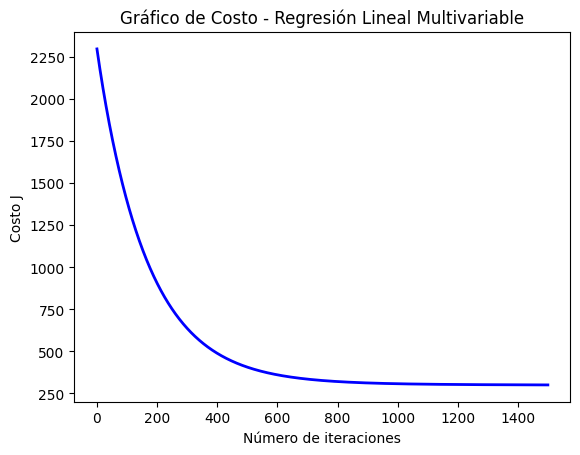

In [102]:
alpha_lin = 0.003
num_iters_lin = 1500

theta_lin = np.zeros(X_ready.shape[1])
theta_lin, J_history_lin = gradientDescentMulti(X_ready, y, theta_lin, alpha_lin, num_iters_lin)

pyplot.plot(np.arange(len(J_history_lin)), J_history_lin, lw=2, color='blue')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Gráfico de Costo - Regresión Lineal Multivariable')
pyplot.show()

Regreción Polinómica

In [103]:
pf = PolynomialFeatures(degree=2, include_bias=False)
X_poly = pf.fit_transform(X)
print(X.shape)

X_poly_norm, mu_poly, sigma_poly = featureNormalize(X_poly)

X_poly_ready = np.concatenate([np.ones((m, 1)), X_poly_norm], axis=1)



(2500, 20)


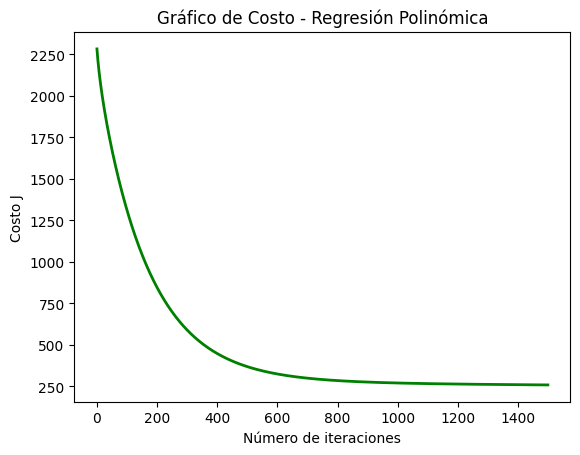

In [104]:
alpha_pol = 0.003
num_iters_pol = 1500

theta_pol = np.zeros(X_poly_ready.shape[1])
theta_pol, J_history_pol = gradientDescentMulti(X_poly_ready, y, theta_pol, alpha_pol, num_iters_pol)

pyplot.plot(np.arange(len(J_history_pol)), J_history_pol, lw=2, color='green')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Gráfico de Costo - Regresión Polinómica')
pyplot.show()


**Ecuación de la Normal**

In [105]:
def normalEqn(X, y):

    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)

    return theta

In [106]:
X_eq = np.concatenate([np.ones((m, 1)), X], axis=1)

theta = normalEqn(X_eq, y)

In [107]:
print(f"{'Real':>10} | {'Lineal Multi':>15} | {'Polinómica':>15} | {'Ecuac. Normal':>15}")
print("-" * 65)

for i in range(150):
    y_real = y[i]

    pred_lin = np.dot(X_ready[i], theta_lin)


    pred_pol = np.dot(X_poly_ready[i], theta_pol)


    pred_eq = np.dot(X_eq[i], theta)


    print(f"{y_real:10.2f} | {pred_lin:15.2f} | {pred_pol:15.2f} | {pred_eq:15.2f}")

      Real |    Lineal Multi |      Polinómica |   Ecuac. Normal
-----------------------------------------------------------------
     29.00 |           35.74 |           33.88 |           34.65
     26.00 |           19.48 |           22.31 |           26.36
     19.00 |           28.78 |           27.49 |           30.84
     22.00 |           32.39 |           30.70 |           32.70
     23.00 |           41.88 |           40.14 |           38.76
     23.00 |           52.02 |           51.40 |           46.86
     11.00 |           64.86 |           67.45 |           62.08
     33.00 |           26.83 |           20.53 |           26.15
     36.00 |           29.96 |           23.48 |           28.10
     31.00 |           32.94 |           26.38 |           30.17
     33.00 |           38.54 |           32.06 |           34.53
     26.00 |           40.40 |           32.41 |            9.79
     27.00 |           17.50 |           21.16 |           27.45
     27.00 |           1

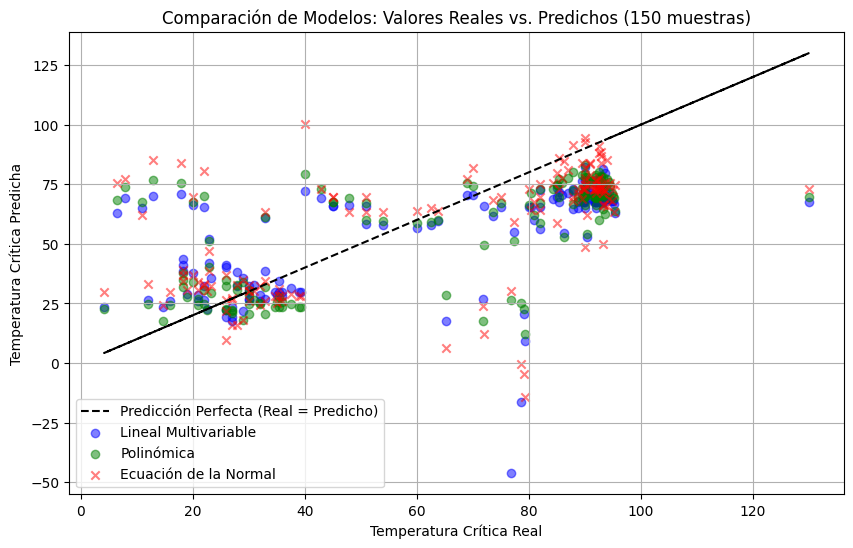

In [108]:
pyplot.figure(figsize=(10, 6))

pyplot.plot(y[:150], y[:150], color='black', linestyle='--', label='Predicción Perfecta (Real = Predicho)')

pyplot.scatter(y[:150], [np.dot(X_ready[i], theta_lin) for i in range(150)], color='blue', alpha=0.5, label='Lineal Multivariable')

pyplot.scatter(y[:150], [np.dot(X_poly_ready[i], theta_pol) for i in range(150)], color='green', alpha=0.5, label='Polinómica')

pyplot.scatter(y[:150], [np.dot(X_eq[i], theta) for i in range(150)], color='red', alpha=0.5, marker='x', label='Ecuación de la Normal')

pyplot.xlabel('Temperatura Crítica Real')
pyplot.ylabel('Temperatura Crítica Predicha')
pyplot.title('Comparación de Modelos: Valores Reales vs. Predichos (150 muestras)')
pyplot.legend()
pyplot.grid(True)
pyplot.show()